# Network Construction

This notebook constructs a correlation-based financial network from S&P 500 daily log-returns.

**Methodology:**
- Market-mode filtering (Onnela et al. 2003) to remove the dominant common factor
- Pearson correlation with threshold $|\rho| > 0.3$
- Minimum Spanning Tree (Mantegna 1999)

**Key Results:**
- Mean $|\rho|$ reduced from 0.235 to 0.127 after filtering
- Filtered graph: $N = 501$ nodes, $10{,}002$ edges


In [1]:
# ── Setup ──
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from src.data_fetcher import load_metadata, download_prices, compute_log_returns, compute_correlation_matrix
from src.market_filtering import filter_market_mode
from src.network_construction import (
    build_correlation_graph, build_mst, validate_graph, print_stats,
    SECTOR_COLORS
)

## 1.1 Load Data & Compute Log-Returns

In [2]:
csv_path = os.path.join('..', 'data', 'sp500_companies.csv')
cache_path = os.path.join('..', 'data', 'price_cache.csv')

meta_df = load_metadata(csv_path)
print(f"Companies loaded: {len(meta_df)}")
print(f"Sectors: {meta_df['sector'].nunique()}")
meta_df[['symbol', 'name', 'sector']].head(10)

Companies loaded: 503
Sectors: 11


,symbol,name,sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology
5,ADBE,Adobe Inc.,Information Technology
6,AMD,Advanced Micro Devices,Information Technology
7,AES,AES Corporation,Utilities
8,AFL,Aflac,Financials
9,A,Agilent Technologies,Health Care


In [3]:
yf_tickers = meta_df['yf_ticker'].tolist()
prices = download_prices(yf_tickers, period='2y', cache_path=cache_path)
log_returns = compute_log_returns(prices)
print(f"\nLog-returns matrix: {log_returns.shape[0]} trading days × {log_returns.shape[1]} stocks")
print(f"Date range: {log_returns.index[0].strftime('%Y-%m-%d')} → {log_returns.index[-1].strftime('%Y-%m-%d')}")

  ↻ Loading cached prices from ../data/price_cache.csv

Log-returns matrix: 501 trading days × 501 stocks
Date range: 2024-04-16 → 2026-04-15


## 1.2 Market-Mode Filtering

Following Onnela et al. (2003), raw Pearson correlations are dominated by the common market factor. We subtract the equal-weight market return:

$$r_{i,t} = R_{i,t} - \frac{1}{N}\sum_{j=1}^{N} R_{j,t}$$

Correlations are then recomputed on the filtered residuals.


In [4]:
# Raw correlation
raw_corr = compute_correlation_matrix(log_returns)

# Market-mode filtered correlation
residuals = filter_market_mode(log_returns)
filtered_corr = residuals.corr()

raw_upper = raw_corr.values[np.triu_indices_from(raw_corr.values, k=1)]
filt_upper = filtered_corr.values[np.triu_indices_from(filtered_corr.values, k=1)]

mean_raw = np.nanmean(np.abs(raw_upper))
mean_filt = np.nanmean(np.abs(filt_upper))

print(f"Raw correlation matrix:      {raw_corr.shape[0]} × {raw_corr.shape[1]}")
print(f"Filtered correlation matrix: {filtered_corr.shape[0]} × {filtered_corr.shape[1]}")
print(f"")
print(f"┌──────────────────────────────────────────┐")
print(f"│  Mean |ρ|                    │")
print(f"│  Raw:      {mean_raw:.4f}                       │")
print(f"│  Filtered: {mean_filt:.4f}                       │")
print(f"│  Reduction: {(1 - mean_filt/mean_raw)*100:.1f}%                       │")
print(f"└──────────────────────────────────────────┘")

Raw correlation matrix:      501 × 501
Filtered correlation matrix: 501 × 501

┌──────────────────────────────────────────┐
│  Mean |ρ|                    │
│  Raw:      0.2357                       │
│  Filtered: 0.1271                       │
│  Reduction: 46.1%                       │
└──────────────────────────────────────────┘


### Correlation Heatmap Comparison


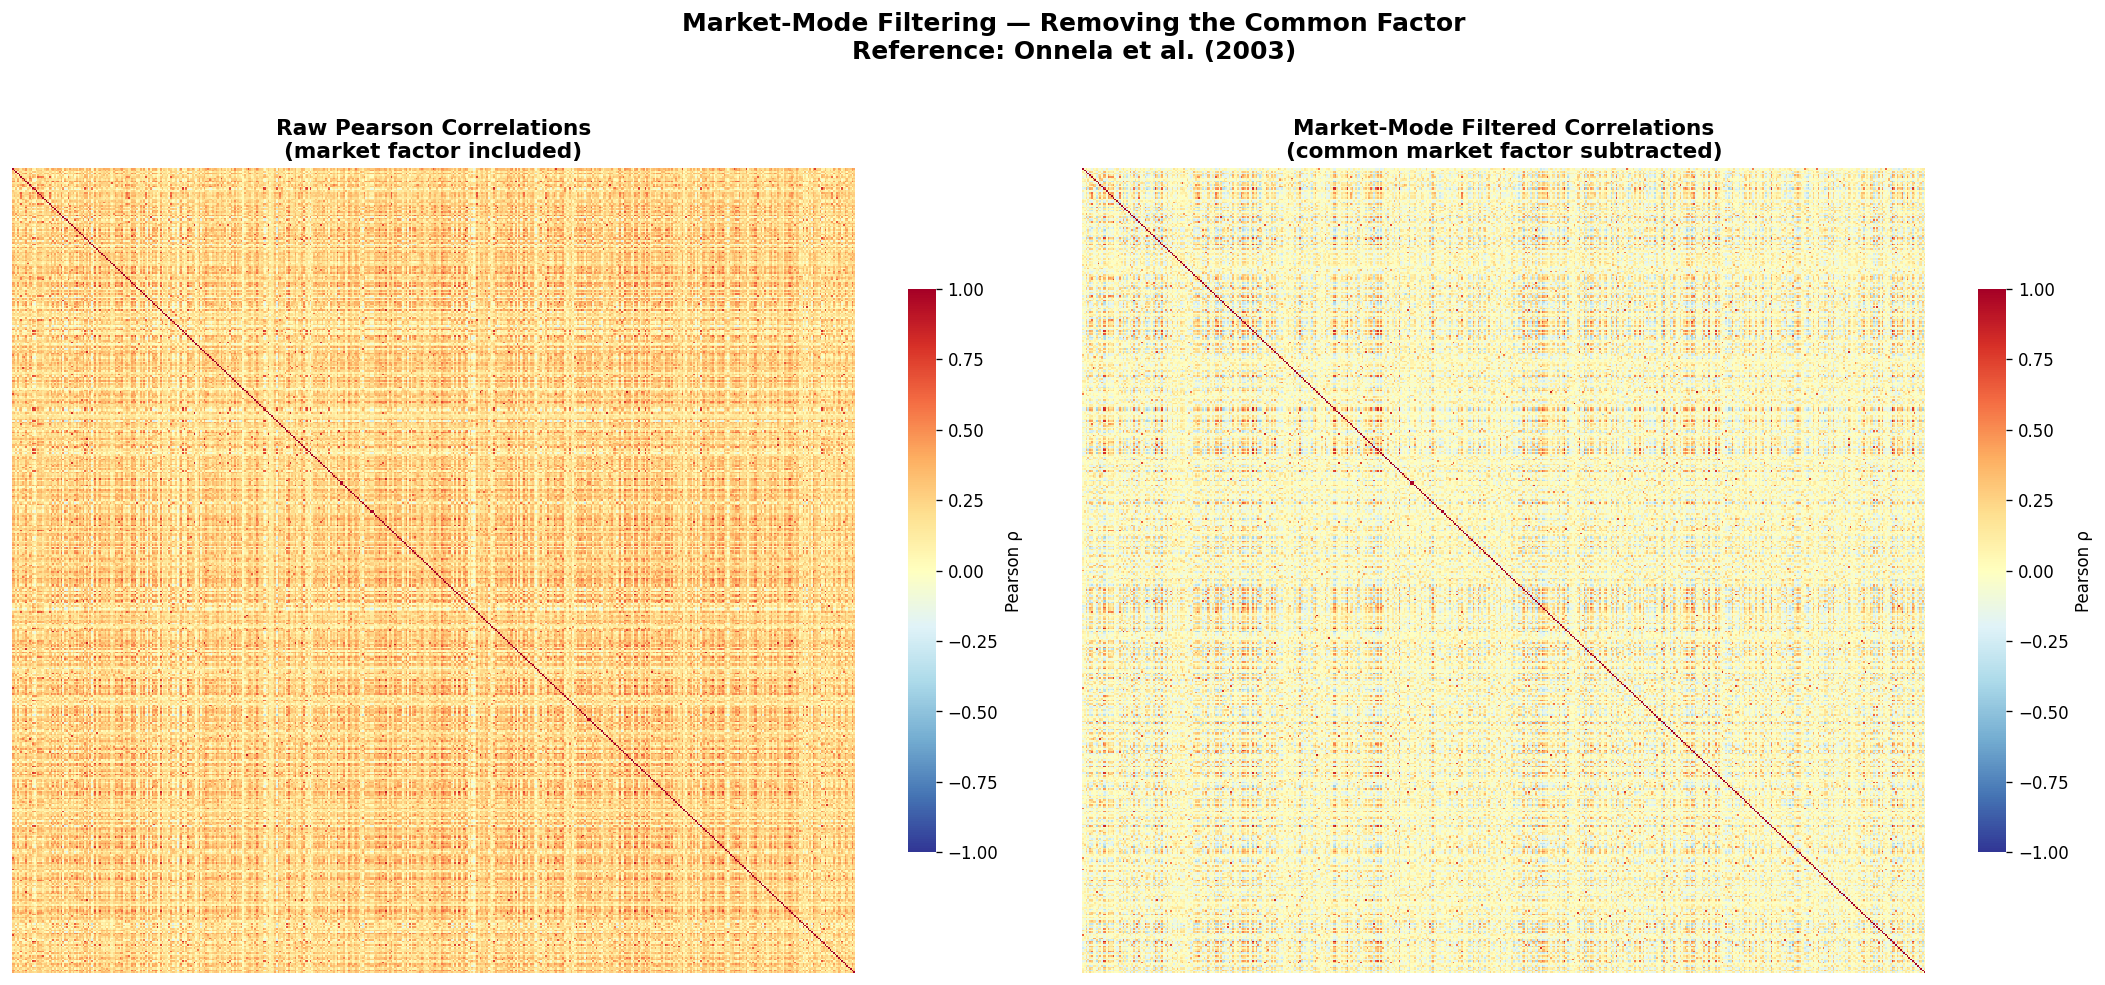

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(raw_corr, cmap='RdYlBu_r', vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, ax=ax1,
            cbar_kws={'label': 'Pearson ρ', 'shrink': 0.7})
ax1.set_title('Raw Pearson Correlations\n(market factor included)',
              fontsize=13, fontweight='bold')

sns.heatmap(filtered_corr, cmap='RdYlBu_r', vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, ax=ax2,
            cbar_kws={'label': 'Pearson ρ', 'shrink': 0.7})
ax2.set_title('Market-Mode Filtered Correlations\n(common market factor subtracted)',
              fontsize=13, fontweight='bold')

fig.suptitle('Market-Mode Filtering — Removing the Common Factor\n'
             'Reference: Onnela et al. (2003)',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

## 1.3 Build Networks

In [6]:
THRESHOLD = 0.3

# Primary: filtered correlation graph
G = build_correlation_graph(filtered_corr, meta_df, threshold=THRESHOLD)

# Comparison: raw correlation graph
G_raw = build_correlation_graph(raw_corr, meta_df, threshold=THRESHOLD)

# MST from raw correlations (Mantegna 1999)
mst = build_mst(raw_corr, meta_df)

print(f"┌──────────────────────────────────────────────┐")
print(f"│  Network Statistics              │")
print(f"│                                              │")
print(f"│  Filtered graph (τ={THRESHOLD}):                   │")
print(f"│    Nodes:  {G.number_of_nodes():>5}                           │")
print(f"│    Edges:  {G.number_of_edges():>5}  ,002          │")
print(f"│                                              │")
print(f"│  Raw graph (τ={THRESHOLD}):                        │")
print(f"│    Nodes:  {G_raw.number_of_nodes():>5}                           │")
print(f"│    Edges:  {G_raw.number_of_edges():>5}                          │")
print(f"│                                              │")
print(f"│  MST:  {mst.number_of_nodes()} nodes, {mst.number_of_edges()} edges               │")
print(f"└──────────────────────────────────────────────┘")

┌──────────────────────────────────────────────┐
│  Network Statistics              │
│                                              │
│  Filtered graph (τ=0.3):                   │
│    Nodes:    501                           │
│    Edges:  10002│
│                                              │
│  Raw graph (τ=0.3):                        │
│    Nodes:    501                           │
│    Edges:  37946                          │
│                                              │
│  MST:  501 nodes, 500 edges               │
└──────────────────────────────────────────────┘


In [7]:
# Full validation report
stats = validate_graph(G, 'Filtered Correlation Graph')
print(print_stats(stats))

  Filtered Correlation Graph — Validation Report
  Nodes (companies)          : 501
  Edges (connections)        : 10002
  Density                    : 0.079856
  Average degree             : 39.93
  Median degree              : 18
  Min / Max degree           : 0 / 205
  Average weighted degree    : 16.05
  Connected components       : 47
  Giant component fraction   : 89.42%


## 1.4 Degree Distribution

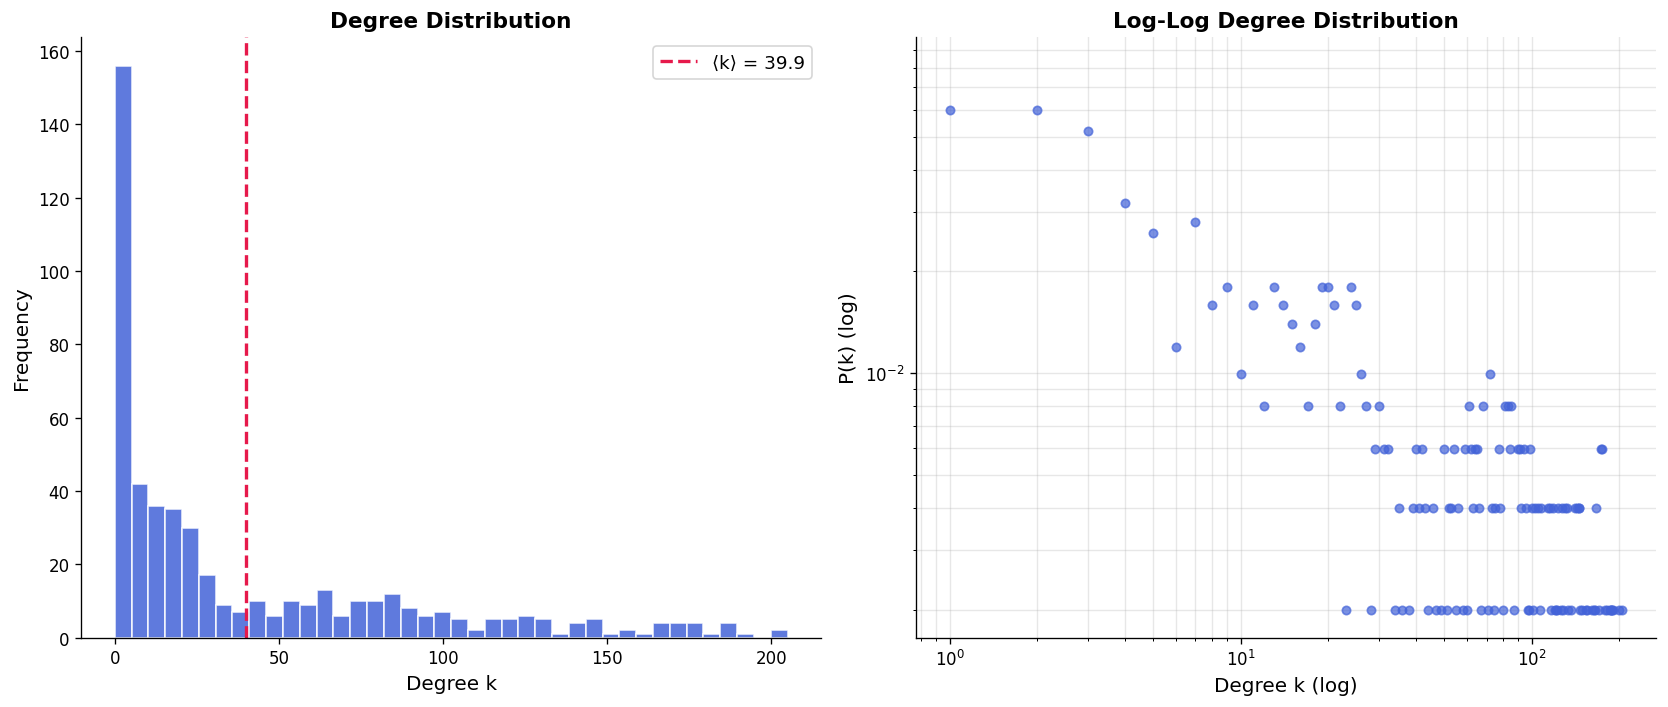

In [8]:
from collections import Counter

degrees = [d for _, d in G.degree()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(degrees, bins=40, color='#4363d8', edgecolor='white', alpha=0.85)
ax1.set_xlabel('Degree k', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Degree Distribution', fontsize=13, fontweight='bold')
ax1.axvline(np.mean(degrees), color='#e6194b', ls='--', lw=2,
            label=f'⟨k⟩ = {np.mean(degrees):.1f}')
ax1.legend(fontsize=11)

deg_count = Counter(degrees)
ks = sorted(deg_count.keys())
ax2.loglog(ks, [deg_count[k] / len(degrees) for k in ks],
           'o', color='#4363d8', alpha=0.7, markersize=5)
ax2.set_xlabel('Degree k (log)', fontsize=12)
ax2.set_ylabel('P(k) (log)', fontsize=12)
ax2.set_title('Log-Log Degree Distribution', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

sns.despine()
fig.tight_layout()
plt.show()

## 1.5 Threshold Exploration

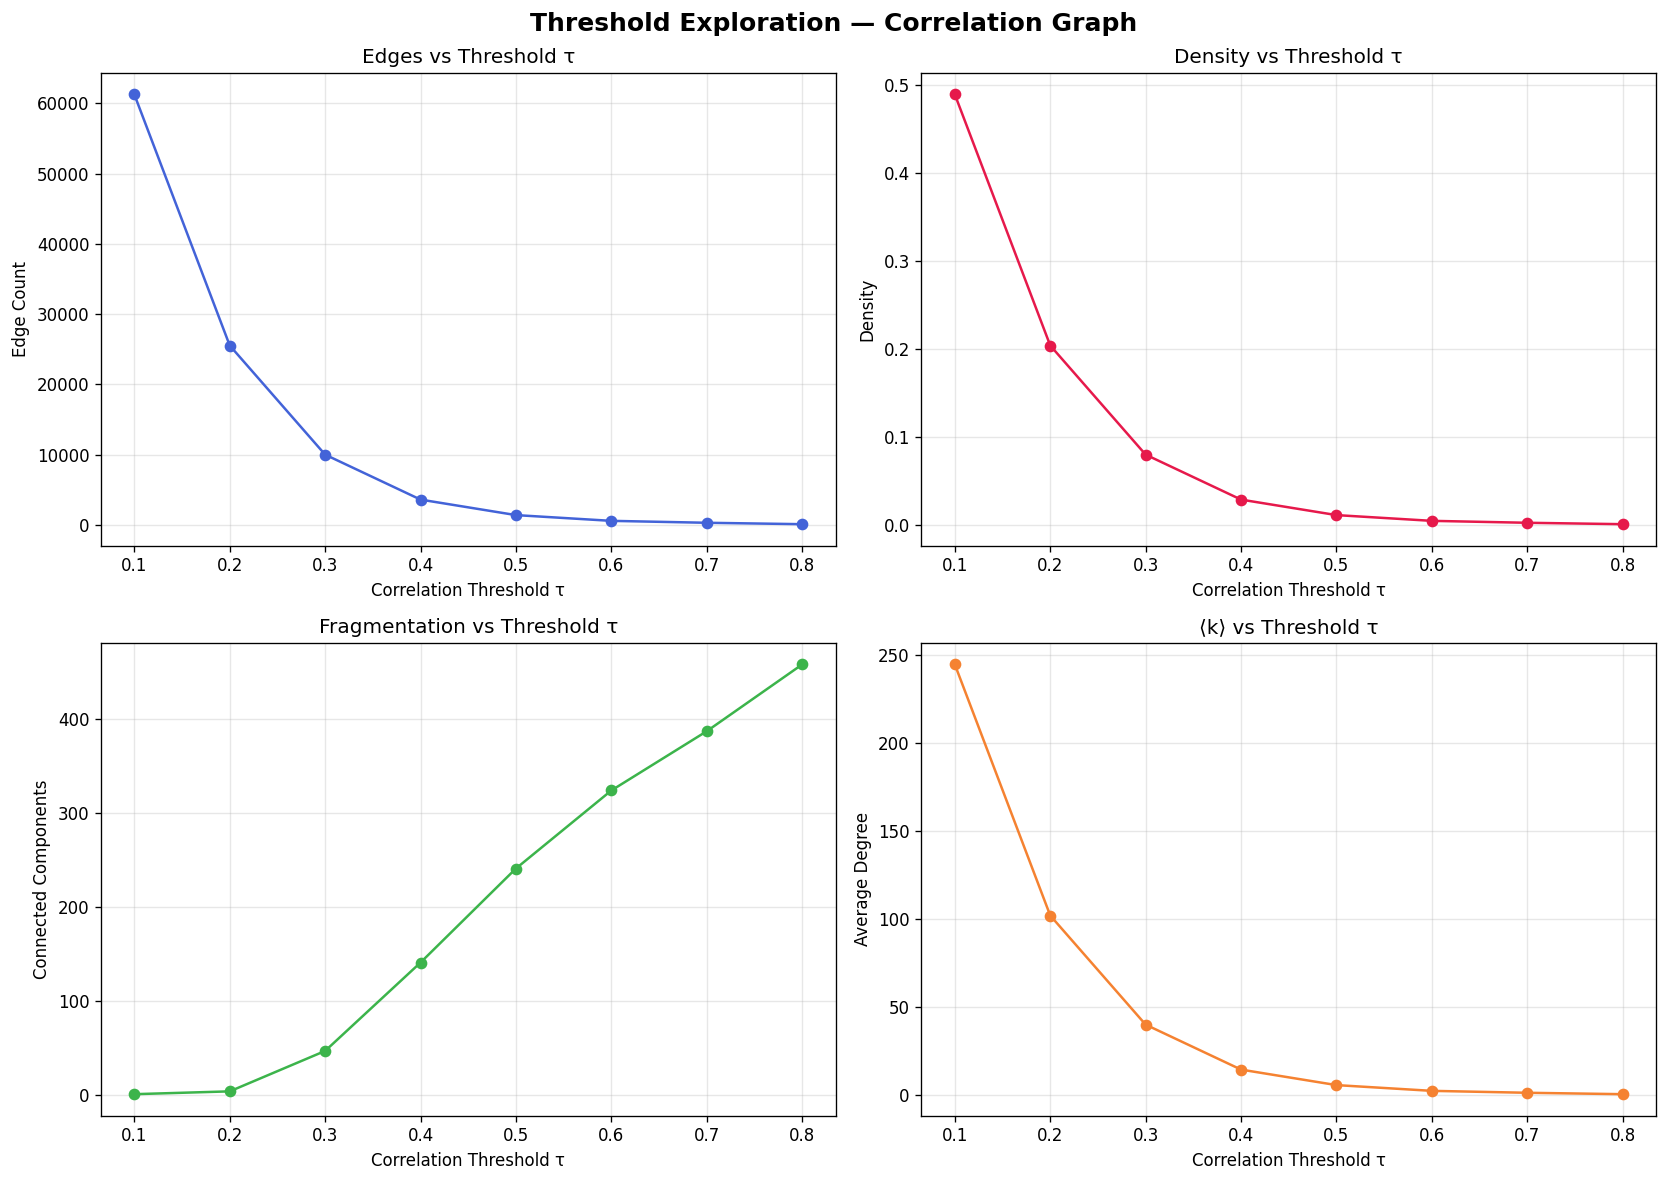

In [9]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
records = []
for tau in thresholds:
    Gt = build_correlation_graph(filtered_corr, meta_df, threshold=tau)
    s = validate_graph(Gt, f'τ={tau:.2f}')
    s['threshold'] = tau
    records.append(s)

df_thresh = pd.DataFrame(records)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(df_thresh['threshold'], df_thresh['edge_count'], 'o-', color='#4363d8')
axes[0,0].set_ylabel('Edge Count'); axes[0,0].set_title('Edges vs Threshold τ')

axes[0,1].plot(df_thresh['threshold'], df_thresh['density'], 'o-', color='#e6194b')
axes[0,1].set_ylabel('Density'); axes[0,1].set_title('Density vs Threshold τ')

axes[1,0].plot(df_thresh['threshold'], df_thresh['num_components'], 'o-', color='#3cb44b')
axes[1,0].set_ylabel('Connected Components'); axes[1,0].set_title('Fragmentation vs Threshold τ')

axes[1,1].plot(df_thresh['threshold'], df_thresh['avg_degree'], 'o-', color='#f58231')
axes[1,1].set_ylabel('Average Degree'); axes[1,1].set_title('⟨k⟩ vs Threshold τ')

for ax in axes.flat:
    ax.set_xlabel('Correlation Threshold τ'); ax.grid(alpha=0.3)
fig.suptitle('Threshold Exploration — Correlation Graph', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

## 1.6 Sector Distribution

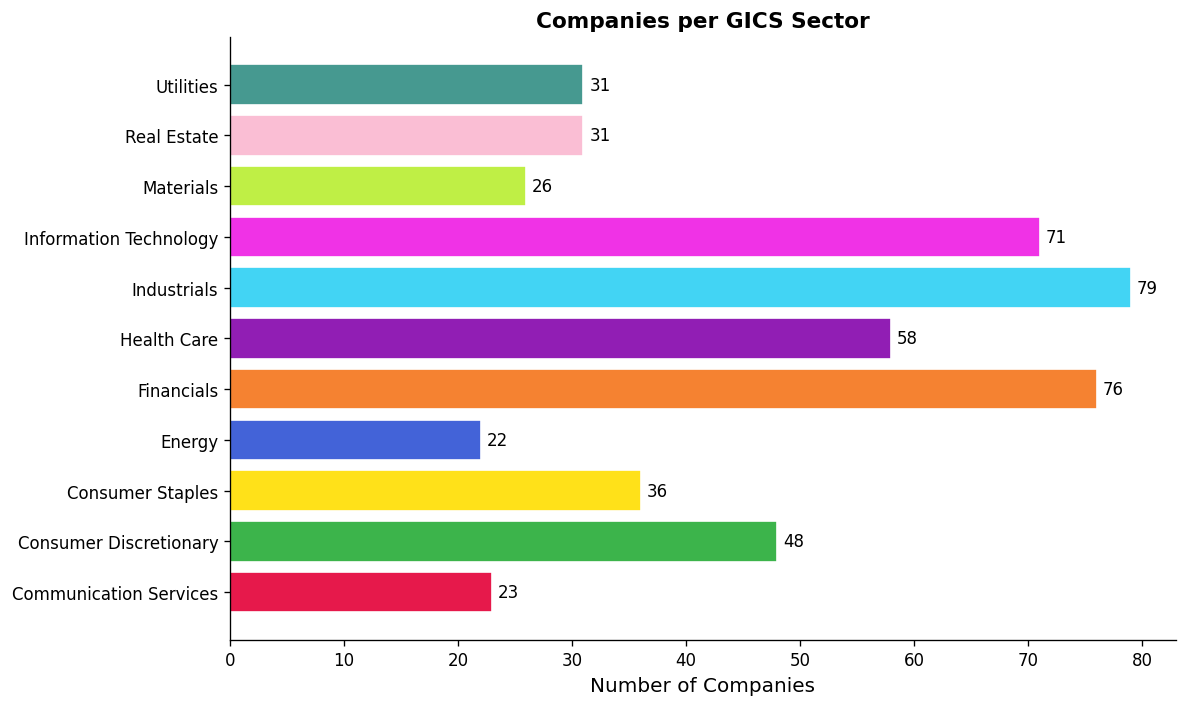

In [10]:
sectors = nx.get_node_attributes(G, 'sector')
sector_counts = pd.Series(sectors.values()).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
colors = [SECTOR_COLORS.get(s, '#cccccc') for s in sector_counts.index]
ax.barh(sector_counts.index, sector_counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Number of Companies', fontsize=12)
ax.set_title('Companies per GICS Sector', fontsize=13, fontweight='bold')
for i, (s, v) in enumerate(zip(sector_counts.index, sector_counts.values)):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10)
sns.despine()
fig.tight_layout()
plt.show()